Notebook to analyze the humber of cryptic pockets we find

In [1]:
import os

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


/tmp/ipykernel_48864/610567014.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


### Top cryptic pockets

In [ ]:
# Load the CSV
csv_filepath = "/home/alex/sshfs_mountpoints/verde/Documents/pocket_tool/results/02_cryptic_pocket_detection/00_detecting_based_on_volume/output_251020/cryptic_pockets.csv"
top_df = pd.read_csv(csv_filepath, sep=";")

# # Load CSV containing the class per dynid
# csv_filepath = "/home/alex/sshfs_mountpoints/verde/Documents/pocket_tool/results/04_combine_pockets_pdb/00_aligning/align.csv"
# align_df = pd.read_csv(csv_filepath, sep=";")
# dynid_class_df = align_df[["dynid", "uniprot_name"]].drop_duplicates().set_index("dynid")

# # Filter for class A only
# top_df = top_df.join(dynid_class_df, on="dynid")
# top_df

FileNotFoundError: [Errno 2] No such file or directory: '/home/alex/sshfs_mountpoints/verde/Documents/pocket_tool/results/02_cryptic_pocket_detection/00_detecting_based_on_volume/output_251020/cryptic_pockets.csv'

In [39]:
top_df_m = top_df.copy()
top_df_m = top_df_m[top_df_m["n_closed_start"] > 100]
top_df_m = top_df_m[top_df_m["n_max_open"] > 100]
top_df_m.sort_values("dyn_id", ascending=True)
# top_df_m.to_csv("/home/alex/sshfs_mountpoints/verde/Documents/pocket_tool/results/02_cryptic_pocket_detection/01_top_scoring_100frames/00_aligning_structures/output_251022/cryptic_pockets_filtered_100f_100f.csv", sep=";", index=False)

,dyn_id,traj_id,pocket_id,n_closed_start,n_max_open,perc_open,perc_closed,perc_inter,n_transitions
598,24,10293,15,138,334,69.438669,28.690229,1.871102,1
1009,33,10366,3,197,129,30.561331,45.945946,23.492723,3
1072,34,10374,7,154,141,54.677755,32.016632,13.305613,1
1147,35,10387,25,359,103,21.413721,74.636175,3.950104,1
1199,36,10398,9,146,182,37.837838,41.787942,20.374220,1
1250,37,10406,6,179,198,41.164241,43.035343,15.800416,1
1292,37,10408,5,105,239,58.627859,23.076923,18.295218,3
1658,43,10460,4,108,108,31.392931,23.908524,44.698545,3
1670,44,10462,15,205,124,53.014553,42.619543,4.365904,1
2126,52,10530,0,103,177,43.451143,31.392931,25.155925,1


### Number of cryptic pockets detected

In [2]:
csv_path = "/home/alex/sshfs_mountpoints/verde/Documents/pocket_tool/results/02_cryptic_pocket_detection/00_detecting_based_on_volume/output_251022/cryptic_pockets.csv"
df = pd.read_csv(csv_path, sep=";")
df

,dyn_id,traj_id,pocket_id,n_closed_start,n_max_open,perc_open,perc_closed,perc_inter,n_transitions
0,4,10140,0,0,289,100.000000,0.000000,0.000000,0
1,4,10140,10,0,82,64.013841,0.000000,35.986159,0
2,4,10140,11,289,0,0.000000,100.000000,0.000000,0
3,4,10140,12,289,0,0.000000,100.000000,0.000000,0
4,4,10140,13,289,0,0.000000,100.000000,0.000000,0
...,...,...,...,...,...,...,...,...,...
20508,1111,18511,5,0,481,100.000000,0.000000,0.000000,0
20509,1111,18511,6,0,455,96.673597,0.000000,3.326403,0
20510,1111,18511,7,0,481,100.000000,0.000000,0.000000,0
20511,1111,18511,8,0,21,23.492723,0.000000,76.507277,0


These are the cryptic pockets we find when we consider cryptic as closed for at least 10% of the simulation (50 ns) and open for the same amount of time

In [13]:
df_m = df.copy()
df_m = df_m[df_m["perc_open"] > 10]
df_m = df_m[df_m["perc_closed"] > 10]
df_m
# df_m.to_csv("/home/alex/sshfs_mountpoints/verde/Documents/pocket_tool/results/02_cryptic_pocket_detection/00_detecting_based_on_volume/output_251022/cryptic_pockets_filtered_10perc.csv", sep=";", index=False)

,dyn_id,traj_id,pocket_id,n_closed_start,n_max_open,perc_open,perc_closed,perc_inter,n_transitions
22,6,10150,0,0,188,50.131234,30.183727,19.685039,1
23,6,10150,10,0,103,46.981627,41.994751,11.023622,1
27,6,10150,14,0,229,60.104987,37.795276,2.099738,1
28,6,10150,15,0,210,55.118110,39.895013,4.986877,1
30,6,10150,1,0,212,57.480315,38.845144,3.674541,1
...,...,...,...,...,...,...,...,...,...
20487,1111,18509,9,68,33,15.800416,44.906445,39.293139,2
20493,1111,18510,3,0,28,14.968815,64.864865,20.166320,1
20494,1111,18510,4,0,37,16.839917,10.810811,72.349272,3
20499,1111,18510,9,0,174,61.954262,11.434511,26.611227,3


If we also add the condition to start as open, we have fewer:

In [9]:
df_m = df.copy()
df_m = df_m[df_m["perc_open"] > 10]
df_m = df_m[df_m["perc_closed"] > 10]
df_m = df_m[df_m["n_closed_start"] > 1] # 5 ns
# df_m.to_csv("/home/alex/sshfs_mountpoints/verde/Documents/pocket_tool/results/02_cryptic_pocket_detection/00_detecting_based_on_volume/cryptic_pockets_filtered_10perc_and_closestart.csv", sep=";", index=False)
df_m

,dyn_id,traj_id,pocket_id,n_closed_start,n_max_open,perc_open,perc_closed,perc_inter
62,7,10166,8,2,53,29.281768,57.458564,13.259669
128,11,10187,0,34,85,26.403326,53.430353,20.166320
141,11,10187,4,4,31,13.721414,49.272349,37.006237
142,11,10187,5,64,102,29.106029,61.954262,8.939709
160,12,10193,9,224,27,17.879418,46.569647,35.550936
...,...,...,...,...,...,...,...,...
23710,1109,18493,4,2,61,46.985447,11.018711,41.995842
23713,1109,18493,7,7,194,69.022869,10.602911,20.374220
23719,1110,18501,5,102,72,26.819127,35.343035,37.837838
23723,1110,18502,3,8,64,20.166320,19.958420,59.875260


### Location of cryptic pockets

In [14]:
# Load your pocket location data
csv_path = "/home/alex/sshfs_mountpoints/verde/Documents/pocket_tool/results/02_cryptic_pocket_detection/02_selecting_10percent/01_360location/pocket_360_locations.csv"  # Update this path
pocket_df = pd.read_csv(csv_path)

# Filter to remove duplicates within 10-degree bins (0-9, 10-19, 20-29, etc.) 
# but only for the same individual pocket (same dynid, trajid, pocketid)
pocket_df['angle_bin'] = (pocket_df['angle_deg'] // 10) * 10  # Create bin labels: 0, 10, 20, 30...
pocket_df = pocket_df.drop_duplicates(subset=['dynid', 'trajid', 'pocketid', 'angle_bin'], keep='first')

pocket_df


,dynid,trajid,pocketid,vertical_position,angle_deg,angle_bin
0,41,10438,19,IC,335,330
2,41,10438,19,IC,341,340
17,41,10438,19,IC,351,350
39,70,10691,0,MID,352,350
41,70,10691,0,MID,348,340
...,...,...,...,...,...,...
87882,822,15925,6,IC,7,0
87906,24,10295,7,IC,63,60
87907,24,10295,7,IC,73,70
87913,24,10295,7,IC,80,80


Min percentage in a bin: 1.75%
Max percentage in a bin: 4.83%


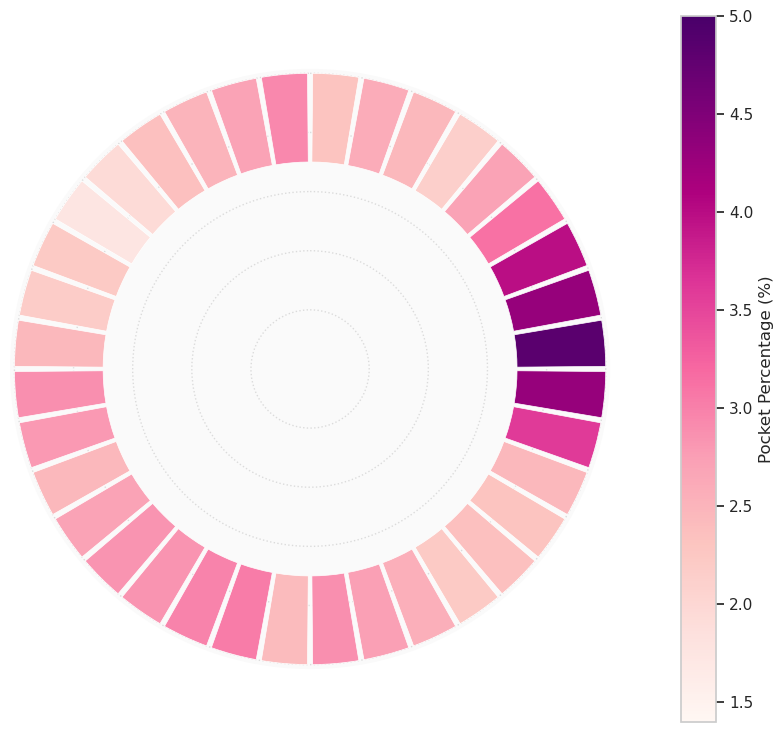

In [38]:
vertical_position = 'ec'

# Get the total number of unique pockets.
n_pockets = pocket_df.groupby(by=["dynid", "trajid", "pocketid"]).size().size

# Filter data for the specified vertical position.
df_mod = pocket_df[pocket_df["vertical_position"] == vertical_position.upper()]
angles_deg = df_mod['angle_bin'].values

# Create circular heatmap with discrete 10-degree bins showing pocket percentages

# Create 36 bins of 10 degrees each
bin_width = 10  # degrees
bins = np.arange(0, 360 + bin_width, bin_width)
bin_centers = (bins[:-1] + bins[1:]) / 2.0

# Count pockets in each bin
counts, _ = np.histogram(angles_deg, bins=bins)
total_pockets = len(angles_deg)

# Convert counts to percentages
percentages = (counts / total_pockets) * 100

# Convert to radians for polar plot
theta = np.deg2rad(bin_centers)
width = np.deg2rad(bin_width)

# Fixed color scale
scale_min, scale_max = 1.4, 5.0
norm = plt.Normalize(scale_min, scale_max)
cmap = plt.cm.RdPu

# Create circular heatmap
fig, ax = plt.subplots(figsize=(8,8), subplot_kw={'projection': 'polar'})
ax.set_facecolor('#fafafa')

# Plot as ring with discrete bins
r_inner, r_outer = 0.7, 1.0

for angle, perc in zip(theta, percentages):
    color = cmap(norm(perc))
    ax.bar(angle, r_outer - r_inner, width=width*0.9, bottom=r_inner,
           color=color, edgecolor='white', linewidth=0.5)

# Aesthetics
ax.set_yticklabels([])
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_xticks([])
ax.set_xticklabels([])
ax.grid(color='gray', alpha=0.25, linestyle=':')
ax.spines['polar'].set_visible(False)

# Add colorbar with fixed 0-6% scale
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # for matplotlib < 3.6 compatibility
cbar = plt.colorbar(sm, ax=ax, pad=0.1, fraction=0.05)
cbar.set_label('Pocket Percentage (%)', fontsize=12)

plt.tight_layout()
# plt.show()

# Show minimum and maximum values on a bin
print(f"Min percentage in a bin: {percentages.min():.2f}%")
print(f"Max percentage in a bin: {percentages.max():.2f}%")

figures_dir = "/home/alex/sshfs_mountpoints/verde/Documents/pocket_tool/docs/figures/raw"
plt.savefig(os.path.join(figures_dir, f"cryptic_pocket_dist_{vertical_position}.svg"))

In [53]:
def coord_to_angle(x, y, origin=(0, 0), reference='y', clockwise=True, degrees=True, return_distance=True):
    """
    Convert 2D coordinate(s) (x, y) to angle(s) in a 0-360 range and optionally return distance(s).

    Parameters
    - x, y : scalar or array-like
    - origin : tuple (ox, oy) to subtract before computing angle
    - reference : 'x' or 'y'
        * 'x' -> 0° at +X axis
        * 'y' -> 0° at +Y axis
    - clockwise : bool
        * False -> angles increase counter-clockwise
        * True  -> angles increase clockwise
    - degrees : bool, if True return degrees, else return radians
    - return_distance : bool, if True also return distance(s) to origin

    Returns
    - angle(s) as numpy scalar or ndarray in [0, 360) (or radians in [0, 2*pi) if degrees=False)
    - if return_distance=True also returns distance(s) (same shape as angle)
    """
    ox, oy = origin
    xa = np.asarray(x) - ox
    ya = np.asarray(y) - oy

    # distance to origin
    dist = np.hypot(xa, ya)

    # angle from +X axis, CCW positive, range [0, 360)
    angle_deg = (np.degrees(np.arctan2(ya, xa)) + 360) % 360

    if reference.lower() == 'x':
        if clockwise:
            angle_deg = (-angle_deg) % 360
        # else keep as is (0 at +X, CCW positive)
    elif reference.lower() == 'y':
        if clockwise:
            # 0 at +Y, clockwise positive
            angle_deg = (90 - angle_deg) % 360
        else:
            # 0 at +Y, CCW positive
            angle_deg = (angle_deg - 90) % 360
    else:
        raise ValueError("reference must be 'x' or 'y'")

    if degrees:
        angle = angle_deg
    else:
        angle = np.deg2rad(angle_deg)

    if return_distance:
        return angle, dist
    else:
        return angle
    
def plot_angular_points(angles_deg, distances, labels=None,
                        figsize=(6,6), cmap=plt.cm.viridis, marker='o',
                        marker_size=60, spine_visible=False, save_path=None):
    """
    Plot points on a circular (polar) plot given angles in degrees and radial distances.
    angles_deg : array-like (degrees, 0..360, 0 at North by default in this plot)
    distances  : array-like (same shape as angles_deg) radial distance from center (0..max)
    labels     : optional list of strings for point labels
    save_path  : optional path to save the figure (svg/png)
    """
    angles_deg = np.asarray(angles_deg)
    distances = np.asarray(distances)
    if angles_deg.shape != distances.shape:
        raise ValueError("angles_deg and distances must have the same shape")

    # Convert to radians for polar plotting
    theta = np.deg2rad(angles_deg % 360)

    # Normalize distances to determine colors
    norm = plt.Normalize(vmin=np.nanmin(distances), vmax=np.nanmax(distances))
    colors = cmap(norm(distances))

    fig, ax = plt.subplots(figsize=figsize, subplot_kw={'projection': 'polar'})
    ax.set_facecolor('#fafafa')

    # Plot spokes (lines from center to each point) and points
    for th, r, c in zip(theta, distances, colors):
        ax.plot([th, th], [0, r], color=c, linewidth=1.2, alpha=0.9)
    sc = ax.scatter(theta, distances, c=distances, cmap=cmap, s=marker_size, edgecolor='k', linewidth=0.4)

    # Add labels slightly beyond each point if provided
    if labels is not None:
        for th, r, lab in zip(theta, distances, labels):
            # put text a little further out than r
            offset = (np.nanmax(distances) or 1) * 0.03
            ax.text(th, r + offset, lab, ha='center', va='center', fontsize=8, rotation=0)

    # Aesthetics: set zero to North and clockwise direction like earlier cells
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    # Remove radial labels / reduce clutter
    ax.set_yticklabels([])
    ax.set_xticks([])

    if not spine_visible:
        ax.spines['polar'].set_visible(False)

    # Add colorbar for radial distance
    cbar = fig.colorbar(sc, ax=ax, pad=0.12, fraction=0.06)
    cbar.set_label("Distance (arb. units)")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
    return fig, ax


Extracellular angles:
TM1 (356.6426135340235, 25.95454680783311)
TM2 (328.85585348683946, 15.79681296971006)
TM3 (280.9087080835408, 11.202428308183901)
TM4 (194.38463805440517, 8.775101139018284)
TM5 (148.11577161077213, 11.529622717157746)
TM6 (111.7562876028519, 11.789800676856245)
TM7 (32.543262415747904, 12.194752970027723)


(<Figure size 600x600 with 2 Axes>, <PolarAxes: >)

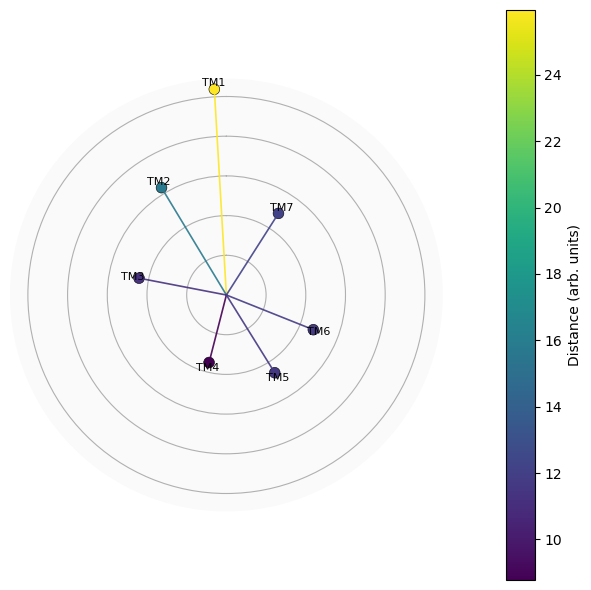

In [57]:
# Extracellular (atoms at height 15 A)
print("Extracellular angles:")
## TM1: ATOM     23  CA  TRP A  32      -1.520  25.908  15.088  1.00 94.60           C
print("TM1", coord_to_angle(-1.52, 25.91))

## TM2: ATOM    469  C   ALA A  92      -8.166  13.516  14.757  1.00 73.86           C
print("TM2", coord_to_angle(-8.17, 13.52))

## TM3: ATOM    593  CA  CYS A 106     -11.002   2.121  15.202  1.00 75.23           C
print("TM3", coord_to_angle(-11.00, 2.12))

## TM4: ATOM   1141  CA  TYR A 174      -2.177  -8.502  15.053  1.00 82.95           C
print("TM4", coord_to_angle(-2.18, -8.50))

## TM5: ATOM   1331  C   GLN A 197       6.092  -9.790  15.044  1.00 68.45           C
print("TM5", coord_to_angle(6.09, -9.79))

## TM6: ATOM   1884  N   VAL A 297      10.947  -4.373  15.064  1.00 73.43           N
print("TM6", coord_to_angle(10.95, -4.37))

## TM7: ATOM   1960  N   GLU A 306       6.558  10.276  16.859  1.00 79.77           N
print("TM7", coord_to_angle(6.56, 10.28))


angles = []
distances = []
labels = ["TM1", "TM2", "TM3", "TM4", "TM5", "TM6", "TM7"]
for angle, distance in [coord_to_angle(-1.52, 25.91),
                        coord_to_angle(-8.17, 13.52),
                        coord_to_angle(-11.00, 2.12),
                        coord_to_angle(-2.18, -8.50),
                        coord_to_angle(6.09, -9.79),
                        coord_to_angle(10.95, -4.37),
                        coord_to_angle(6.56, 10.28)]:
    angles.append(angle)
    distances.append(distance)

plot_angular_points(angles, distances, labels=labels)

Middle TM angles:
TM1 (331.89762481463424, 19.170002608241866)
TM2 (298.60288486702564, 12.073458493737409)
TM3 (263.31684465604644, 6.272623055787746)
TM4 (214.93990550405792, 10.808131198315461)
TM5 (134.06421748849675, 7.793356144819765)
TM6 (42.20329149672415, 9.8546638704727)
TM7 (0.8104963076640388, 11.311131685202856)


(<Figure size 600x600 with 2 Axes>, <PolarAxes: >)

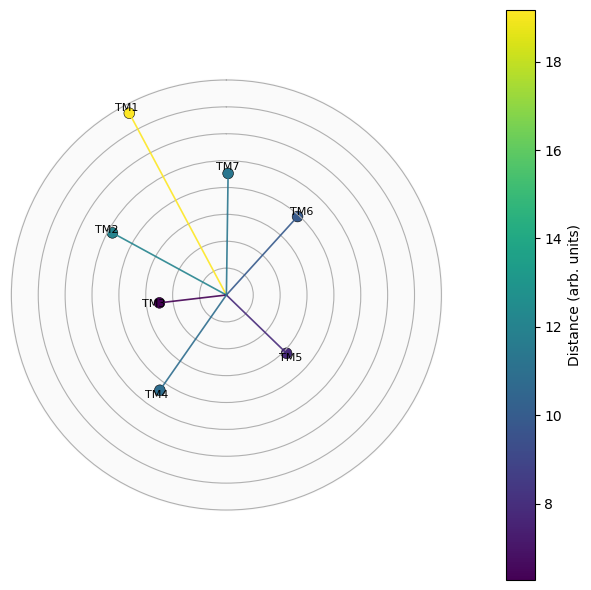

In [58]:
# Middle transmembrane (atoms at height 0 A)
print("Middle TM angles:")

## TM1: ATOM    118  N   LEU A  45      -9.034  16.912   0.350  1.00 78.66           N
print("TM1", coord_to_angle(-9.03, 16.91))

## TM2: ATOM    394  N   VAL A  81     -10.597   5.775  -1.426  1.00 66.65           N
print("TM2", coord_to_angle(-10.60, 5.78))

## TM3: ATOM    676  N   CYS A 116      -6.230  -0.732   1.710  1.00 72.44           N
print("TM3", coord_to_angle(-6.23, -0.73))

## TM4: ATOM   1034  N   SER A 161      -6.192  -8.860  -0.979  1.00 76.74           N
print("TM4", coord_to_angle(-6.19, -8.86))

## TM5: ATOM   1408  C   PHE A 208       5.600  -5.415   0.310  1.00 78.35           C
print("TM5", coord_to_angle(5.60, -5.42))

## TM6: ATOM   1780  CA  CYS A 285       6.619   7.295  -0.036  1.00 76.99           C
print("TM6", coord_to_angle(6.62, 7.30))

## TM7: ATOM   2060  C   VAL A 317       0.164  11.313  -0.422  1.00 72.64           C
print("TM7", coord_to_angle(0.16, 11.31))

angles = []
distances = []
labels = ["TM1", "TM2", "TM3", "TM4", "TM5", "TM6", "TM7"]
for angle, distance in [coord_to_angle(-9.03, 16.91),
                        coord_to_angle(-10.60, 5.78),
                        coord_to_angle(-6.23, -0.73),
                        coord_to_angle(-6.19, -8.86),
                        coord_to_angle(5.60, -5.42),
                        coord_to_angle(6.62, 7.30),
                        coord_to_angle(0.16, 11.31)]:
    angles.append(angle)
    distances.append(distance)

plot_angular_points(angles, distances, labels=labels)

Intracellular angles:
TM1 (304.32757174725737, 17.449174765587053)
TM2 (285.0607729416862, 8.274212953508025)
TM3 (156.0703754129574, 8.850773977455304)
TM4 (228.29720385332325, 11.679524819101161)
TM5 (103.29337356908229, 13.655903485306272)
TM6 (35.14745494530922, 7.8515476181451005)
TM7 (355.0258677811714, 11.302566080319991)


(<Figure size 600x600 with 2 Axes>, <PolarAxes: >)

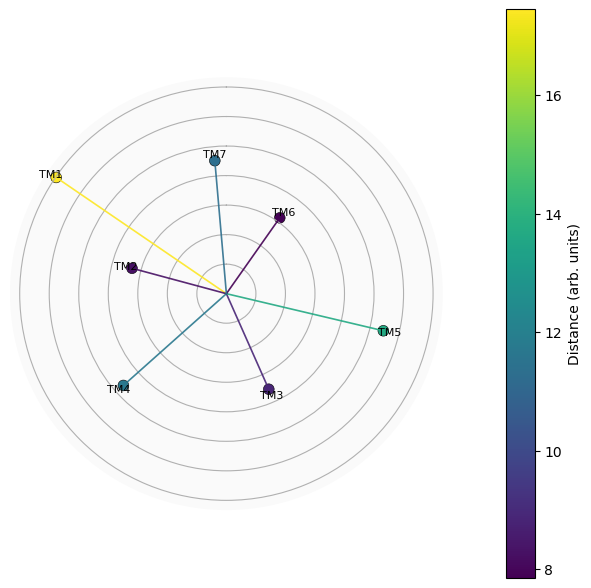

In [59]:
# Intracellular (atoms at height -15 A)
print("Intracellular angles:")
## TM1: ATOM    200  CA  THR A  56     -14.409   9.843 -14.262  1.00 69.62           C
print("TM1", coord_to_angle(-14.41, 9.84))

## TM2: ATOM    305  O   ASN A  69      -7.986   2.152 -15.435  1.00 73.32           O
print("TM2", coord_to_angle(-7.99, 2.15))

## TM3: ATOM    766  CA  VAL A 129       3.589  -8.094 -14.851  1.00 70.68           C
print("TM3", coord_to_angle(3.59, -8.09))

## TM4: ATOM    944  CA  ALA A 150      -8.723  -7.767 -16.193  1.00 74.46           C
print("TM4", coord_to_angle(-8.72, -7.77))

## TM5: ATOM   1512  CA  SER A 220      13.285  -3.137 -14.553  1.00 72.46           C
print("TM5", coord_to_angle(13.29, -3.14))

## TM6: ATOM   1701  C   THR A 274       4.521   6.420 -15.412  1.00 76.51           C
print("TM6", coord_to_angle(4.52, 6.42))

## TM7: ATOM   2126  CA  TYR A 326      -0.980  11.257 -15.160  1.00 76.44           C
print("TM7", coord_to_angle(-0.98, 11.26))

angles = []
distances = []
labels = ["TM1", "TM2", "TM3", "TM4", "TM5", "TM6", "TM7"]
for angle, distance in [coord_to_angle(-14.41, 9.84),
                        coord_to_angle(-7.99, 2.15),
                        coord_to_angle(3.59, -8.09),
                        coord_to_angle(-8.72, -7.77),
                        coord_to_angle(13.29, -3.14),
                        coord_to_angle(4.52, 6.42),
                        coord_to_angle(-0.98, 11.26)]:
    angles.append(angle)
    distances.append(distance)

plot_angular_points(angles, distances, labels=labels)

### Number of transitions between closed and open (and viceversa)

In [42]:
csv_path = "/home/alex/sshfs_mountpoints/verde/Documents/pocket_tool/results/02_cryptic_pocket_detection/00_detecting_based_on_volume/output_251022/cryptic_pockets.csv"
df = pd.read_csv(csv_path, sep=";")
df = df[df["perc_open"] > 10]
df = df[df["perc_closed"] > 10]
df.sort_values("n_transitions", ascending=False).head(20)

,dyn_id,traj_id,pocket_id,n_closed_start,n_max_open,perc_open,perc_closed,perc_inter,n_transitions
9940,197,11861,0,0,118,20.966729,35.969868,43.063402,37
10101,201,11897,12,0,56,14.267407,36.351986,49.380607,28
10105,201,11897,16,15,95,31.482273,23.750534,44.767194,28
10035,199,11888,21,0,107,43.385132,12.809744,43.805124,27
10110,201,11897,5,0,83,36.052969,14.950876,48.996155,22
9949,197,11862,0,0,263,69.418794,13.307985,17.273221,20
10039,199,11888,5,0,163,45.653087,30.533389,23.813524,19
9942,197,11861,2,0,81,15.034526,29.284369,55.681105,16
10041,199,11888,7,0,59,10.121798,35.951281,53.926921,15
4076,90,10871,5,0,112,39.501040,21.621622,38.877339,10


In [44]:
(df['n_transitions'] > 8).sum()

17

Mean number of transitions: 2.76


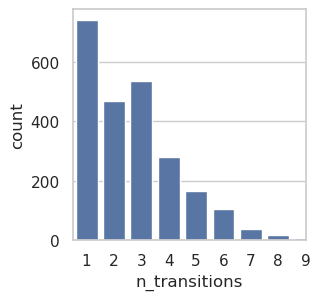

In [46]:
plt.figure(figsize=(3,3))
sns.set_theme(style="whitegrid")

df_m = df.copy()
sns.countplot(x='n_transitions', data=df_m)
plt.xlim(-0.5, 8)

figures_dir = "/home/alex/sshfs_mountpoints/verde/Documents/pocket_tool/docs/figures/raw"
# plt.savefig(os.path.join(figures_dir, f"cryptic_pocket_ntransitions_histogram.svg"))

# Mean number of transitions
mean_transitions = df_m['n_transitions'].mean()
print(f"Mean number of transitions: {mean_transitions:.2f}")
